# B8.5 Quantum Probability & Measurement
<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## B8.5.1 Motivation: Why Quantum Probability and Measurement?

### A New Way of Thinking About Particles

In classical physics, particles have definite positions and velocities at all times — we just might not know them exactly.  
In quantum mechanics, this picture breaks down:

- A particle is described by a **wavefunction**, which spreads out in space.  
- We can only talk about **probabilities** of where we might find it, not certainties.

Understanding this is essential to interpreting what the wavefunction actually tells us.

---

### Making Sense of the Wavefunction

Up to now, we treated $\psi$ mostly as a "wave."  
But **what does it physically mean?**

- Max Born proposed that the **square of the wavefunction’s magnitude** gives the **probability density** of finding a particle at a location.  
- This was a revolutionary shift: quantum mechanics is fundamentally **probabilistic**.

Without this interpretation, the wavefunction would just be math with no connection to experiments.

---

### Measurement and Reality

When we measure a quantum system:

- The act of measurement changes the system.  
- The wavefunction appears to **"collapse"** to a definite outcome.

This is one of the most puzzling and important aspects of quantum theory, and it raises deep questions about what "measurement" really means.

---

### Why It Matters

- This probabilistic interpretation underlies **all of quantum physics**.  
- We use it to calculate **expectation values**, **uncertainties**, and to make predictions for experiments.  
- It connects directly to the **Heisenberg Uncertainty Principle**: probabilities determine standard deviations, which define uncertainty limits.

---

### Why Learn It Now?

Before moving to experiments like the **double-slit** and to solving the Schrödinger equation in Phase A, we need to:

- Learn how to interpret $|\psi|^2$ as a real, physical quantity.  
- Understand how to calculate **average outcomes** and **uncertainties** from a wavefunction.

This is the bridge between **math** and **experiment** in quantum mechanics.

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## B8.5.2 The Born Interpretation

In 1926, Max Born proposed that the wavefunction $\psi(x,t)$ does not describe a particle's exact path, but rather **probability**:

---

### Probability Density

$$
P(x,t) = |\psi(x,t)|^2
$$

- $P(x,t)\,dx =$ probability of finding the particle between $x$ and $x+dx$ at time $t$.

---

### Normalization

The total probability must be 1:

$$
\int_{-\infty}^{\infty} |\psi(x,t)|^2 \, dx = 1
$$

If this is not true initially, we scale $\psi$ appropriately.

---

### Complex Nature of $\psi$

- $\psi$ is generally **complex**: $\psi = a + ib$.
- Only $|\psi|^2 = \psi^* \psi$ has direct physical meaning.

*(This is why we introduced the complex conjugate earlier.)*

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## B8.5.3 Expectation Values and Uncertainty

Quantum mechanics predicts **probabilities**, not definite outcomes.

---

### Expectation (Average) Value

For any quantity $A(x)$:

$$
\langle A \rangle = \int_{-\infty}^{\infty} A(x)\, |\psi(x,t)|^2 \, dx
$$

- $\langle x \rangle$ = average position  
- $\langle p \rangle$ = average momentum (in $p$-space)

---

### Standard Deviation (Uncertainty)

The uncertainty (standard deviation) in $x$:

$$
\Delta x = \sqrt{\langle x^2 \rangle - \langle x \rangle^2}
$$

Same for momentum:

$$
\Delta p = \sqrt{\langle p^2 \rangle - \langle p \rangle^2}
$$

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## B8.5.4 Example: Gaussian Wave Packet

Let’s confirm the normalization and compute expectation values for a Gaussian.

Assume:

$$
\psi(x) = \frac{1}{(2\pi \sigma_x^2)^{1/4}} e^{-x^2/(4\sigma_x^2)}
$$

This is already normalized.

- $\langle x \rangle = 0$ (symmetric around 0)
- $\Delta x = \sigma_x$
- In momentum space: $\Delta p = \hbar/(2\sigma_x)$

This packet **saturates** the uncertainty principle (i.e., it reaches the minimum possible uncertainty product):

$$
\Delta x\, \Delta p = \frac{\hbar}{2}
$$

Let us check:

In [1]:
# Numerical check for Gaussian normalization & expectation values
import numpy as np

x = np.linspace(-10,10,5000)
sigma_x = 1.0

psi = (1/(2*np.pi*sigma_x**2)**0.25) * np.exp(-x**2/(4*sigma_x**2))
prob = np.abs(psi)**2

dx = x[1]-x[0]
normalization = np.sum(prob)*dx
x_mean = np.sum(x*prob)*dx
x2_mean = np.sum(x**2*prob)*dx
delta_x = np.sqrt(x2_mean - x_mean**2)

print(f"Normalization ≈ {normalization:.5f}")
print(f"<x> ≈ {x_mean:.5f}")
print(f"Δx ≈ {delta_x:.5f} (should ≈ σ_x = {sigma_x})")

Normalization ≈ 1.00000
<x> ≈ 0.00000
Δx ≈ 1.00000 (should ≈ σ_x = 1.0)


<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## B8.5.5 Measurement and "Collapse"

### What Does Measurement Mean?

- Before measurement, the particle is described by a **spread-out wavefunction** (probability distribution).
- Measurement gives a single value (e.g., position).  
- After measurement, the wavefunction **collapses** to be localized near that measured value.

---

### Important Notes

- The **Born rule** gives probabilities, not certainties.  
- Repeating the same measurement on identical systems gives a **distribution** following $|\psi|^2$.
- The details of how "collapse" occurs are not fully described in standard quantum mechanics (interpretation issue).

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## B8.5.6 Visualization

Below: **A normalized Gaussian probability density** and how its width affects the likelihood of finding the particle.

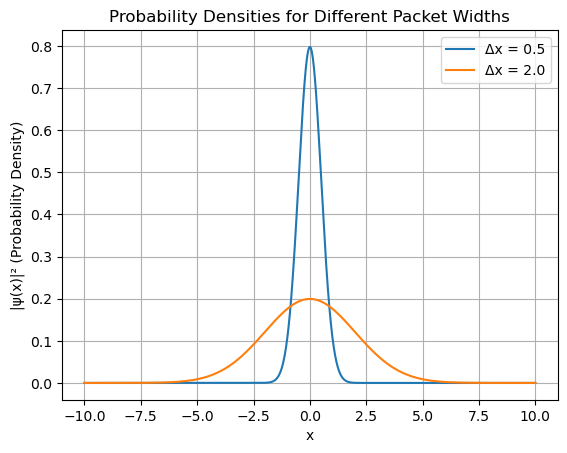

In [2]:
import matplotlib.pyplot as plt

sigma1, sigma2 = 0.5, 2.0
psi1 = (1/(2*np.pi*sigma1**2)**0.25)*np.exp(-x**2/(4*sigma1**2))
psi2 = (1/(2*np.pi*sigma2**2)**0.25)*np.exp(-x**2/(4*sigma2**2))

plt.plot(x, np.abs(psi1)**2, label=f"Δx = {sigma1}")
plt.plot(x, np.abs(psi2)**2, label=f"Δx = {sigma2}")
plt.title("Probability Densities for Different Packet Widths")
plt.xlabel("x")
plt.ylabel("|ψ(x)|² (Probability Density)")
plt.legend()
plt.grid(True)
plt.show()


<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## B8.5.7 Summary

- $|\psi|^2$ gives **probability density** (Born rule).
- Wavefunctions must be **normalized**.
- Expectation values and standard deviations quantify **average outcomes** and **uncertainties**.
- The Heisenberg principle is naturally expressed using these standard deviations.

<hr style="height:2px;border-width:0;color:gray;background-color:gray">